In [1]:
import os
import glob
from datasets.metadata import uci_datasets_info
import pickle
from functools import reduce
from functools import partial
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from scipy.stats import chi2
from datasets.metadata import uci_datasets_info
from utils.process_data import preprocess_dataframe
from utils.measures import *
from utils.clustering import *
from Walker import ActiveDPGMMWalker
import pygad

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
from adjustText import adjust_text
from pandas.plotting import parallel_coordinates
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

/home/bdezoysa/.conda/envs/py310/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
file = f'./results/mod/case_study_p2048.pkl'
if os.path.isfile(file):
    with open(file, 'rb') as f:
        results = pickle.load(f)
        print(results['best_configs'])

[(27, 1.0, 2.0, 1.0), (186, 1.0, 0.9, 0.5), (3, 1.0, 1.0, 0.5)]


In [3]:
overall_bests = []

for name in uci_datasets_info.keys():
    # if name == 'winequality-red':
    #     continue
    
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [512, 1024, 2048]

    measure = 'jsd'
    is_all_done = True
    best_of_each = []
    for pocket_size in pocket_sizes:
        file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)

                best_ratio = -float('inf')
                best_i = 0
                # for i in range(3):
                #     ratio = results['best_scores'][i] / len(results['best_details'][i]['clusters'])
                #     if ratio > best_ratio:
                #         best_ratio = ratio
                #         best_i = i

                best_of_each.append([results['best_scores'][best_i], results['best_details'][best_i], results['best_configs'][best_i], pocket_size])
        else:
            is_all_done = False
            break
    
    if is_all_done:
        the_best = max(best_of_each, key=lambda x: x[0])
        the_row = [name, pocket_size]
        the_row.extend(the_best[2][1:])
        overall_bests.append(the_row)

        with open(f'./results/mod/{name}_{measure}_overall_best.pkl', 'wb') as f:
            pickle.dump(
                {
                    'best_score': the_best[0],
                    'best_detail': the_best[1],
                    'best_config': the_best[2],
                    'pocket_size': the_best[3]
                }, f)

In [43]:
rows = [['dataset', 'jsd', 'kld', 'hellinger', 'tvd']]
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [512, 1024, 2048]

    the_best = []
    for measure in ['jsd', 'kld', 'hellinger', 'tvd']:
        is_all_done = True
        best_of_each = []
        for pocket_size in pocket_sizes:
            file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    # the_values = [results['best_scores'][0]]
                    # the_values.extend(list(results['best_configs'][0])[1:])
                    # best_of_each.append(the_values)
                    # best_ratio = -float('inf')
                    # best_i = -1
                    # for i in range(3):
                    #     # ratio = results['best_scores'][i] / len(results['best_details'][i]['clusters'])
                    #     # if ratio > best_ratio and results['best_configs'][i][3] > 0.0:
                    #     #     best_ratio = ratio
                    #     #     best_i = i
                    #     # else:
                    #     #     print('0 equivalent')

                    #     if results['best_configs'][i][3] > 0.0:
                    #         best_i = i
                        
                    # if best_i == -1:
                    #     print('0 equivalent')

                    # best_i = 0
                    # best_of_each.append(results['best_scores'][best_i])

                    # print(len(results['best_details'][best_i]['clusters']))
                    # print(results['best_configs'][best_i])

                    summary_df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
                    filtered_summary_df = summary_df[(summary_df['lambda'] > 0.0) & (summary_df['num_clusters'] < 100)]
                    # filtered_summary_df['ratio'] = filtered_summary_df['score'] / filtered_summary_df['num_clusters']

                    best_of_each.append(filtered_summary_df[filtered_summary_df['score'] == filtered_summary_df['score'].max()]['score'].iloc[0])
            else:
                is_all_done = False
                break
        
        if is_all_done:
            # the_best.append(max(best_of_each, key=lambda x: x[0]))
            # print(the_best[-1])
            the_best.append(max(best_of_each))
    
    if len(the_best) == 4:
        new_row = [name]
        new_row.extend(the_best)
        rows.append(new_row)

In [44]:
best_df = pd.DataFrame(rows[1:], columns=rows[0])

In [4]:
best_df

,dataset,jsd,kld,hellinger,tvd
0,sepsis_survival_primary_cohort,0.166549,0.085705,0.146934,0.074338
1,social_network_ads,0.659880,1.294180,0.531856,0.617500
2,uk_used_cars_ford,0.722945,2.359558,0.706729,0.758439
3,combined_cycle_power_plant,0.740351,2.468990,0.709108,0.762027
4,protein_tertiary_structure,0.682775,2.019295,0.624162,0.713036
5,gas_turbine_emissions,0.721584,2.210464,0.675395,0.733191
6,naval_propulsion_plants,0.740574,2.345811,0.714096,0.777980
7,winequality-red,0.540316,1.485696,0.498189,0.576790
8,winequality-white,0.532318,1.453447,0.464719,0.614542
9,dry_bean,0.815845,2.773117,0.768455,0.851008


In [5]:
seeds = [20260501, 20260502, 20260503]
syflow_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/syflow_seed_{seed}.csv') for seed in seeds], axis=0)
sdkl_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/sd-kl_seed_{seed}.csv') for seed in seeds], axis=0)
sdmean_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/sd-mean_seed_{seed}.csv') for seed in seeds], axis=0)
rsd_best_df = pd.concat([pd.read_csv(f'../results/real_world/seeds/rsd_seed_{seed}.csv') for seed in seeds], axis=0)

In [6]:
dfs = [syflow_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
syflow_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

dfs = [sdkl_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
sdkl_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

dfs = [sdmean_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
sdmean_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

dfs = [rsd_best_df.groupby(['dataset']).agg({measure: 'max'}).reset_index() for measure in ['jsd', 'kld', 'hellinger', 'tvd']]
rsd_merged_df = reduce(lambda left, right: pd.merge(left, right, on='dataset', how='left'), dfs)

In [7]:
def modify_top_two(improvement, row):
    mod_row = row.astype('float')
    top_values = sorted(mod_row.unique(), reverse=True)
    max_val = top_values[0]
    there_is_second_max = True
    
    if len(top_values) > 1:
        second_max_val = top_values[1]
        if second_max_val == -1:
            there_is_second_max = False
    else:
        second_max_val = max_val

    best_idx = np.nonzero(mod_row == max_val)[0]
    row[mod_row == max_val] = f"\\cellcolor{{bestcolor}}{{{max_val}}}"
    
    if there_is_second_max:
        # second_best_idx = np.nonzero(mod_row == second_max_val)[0]
        row[mod_row == second_max_val] = f"\\cellcolor{{secondcolor}}{{{second_max_val}}}"
        
        if 0 in best_idx:
            improvement.append(max_val - second_max_val)

            # print((max_val - second_max_val) / second_max_val)
        
    return row

In [8]:
combined_dfs = []
improvement = {}
multi_index = [('Dataset', 'dataset')]
for measure in ['jsd', 'kld', 'hellinger', 'tvd']:
    combined_df = best_df[['dataset', measure]].merge(syflow_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_ours', '_syflow')) \
                                            .merge(sdkl_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdkl')) \
                                            .merge(sdmean_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdmean')) \
                                            .merge(rsd_merged_df[['dataset', measure]], on='dataset', how='left', suffixes=('_rsd', '_rsd'))

    combined_df = combined_df.round(3)
    combined_df = combined_df.fillna(-1)
    combined_df = combined_df.astype('object')

    improvement[measure] = []
    partial_modify_top_two = partial(modify_top_two, improvement[measure])

    affected_cols = [f'{measure}{suffix}' for suffix in ['_ours', '_syflow', '_sdkl', '_sdmean', '']]
    combined_df[affected_cols] = combined_df[affected_cols].apply(partial_modify_top_two, axis=1)

    for col in combined_df.columns[1:]:
        multi_index.append((measure.upper(), col))

    if measure != 'jsd':
        combined_dfs.append(combined_df.iloc[:, 1:])
    else:
        combined_dfs.append(combined_df)

final_df = pd.concat(combined_dfs, axis=1)
og_final_df = final_df
final_df.columns = pd.MultiIndex.from_tuples(multi_index)
final_df.replace({-1: "n/a"}, inplace=True)
final_df

Dataset                           JSD  \
                              dataset                      jsd_ours   
0      sepsis_survival_primary_cohort  \cellcolor{bestcolor}{0.167}   
1                  social_network_ads   \cellcolor{bestcolor}{0.66}   
2                   uk_used_cars_ford  \cellcolor{bestcolor}{0.723}   
3          combined_cycle_power_plant   \cellcolor{bestcolor}{0.74}   
4          protein_tertiary_structure  \cellcolor{bestcolor}{0.683}   
5               gas_turbine_emissions  \cellcolor{bestcolor}{0.722}   
6             naval_propulsion_plants  \cellcolor{bestcolor}{0.741}   
7                     winequality-red   \cellcolor{bestcolor}{0.54}   
8                   winequality-white  \cellcolor{bestcolor}{0.532}   
9                            dry_bean  \cellcolor{bestcolor}{0.816}   
10                          insurance                         0.795   
11                              yeast  \cellcolor{bestcolor}{0.672}   
12  steel_industry_energy_consumption  \cellcolor{bestcolor}{0.592}   
13                  superconductivity  \cellcolor{bestcolor}{0.667}   
14                 airfoil_self_noise  \cellcolor{bestcolor}{0.699}   
15                      eeg_eye_state  \cellcolor{bestcolor}{0.411}   
16              hcv_egyptian_patients  \cellcolor{bestcolor}{0.479}   
17     power_consumption_tetouan_city  \cellcolor{bestcolor}{0.766}   
18                         parkinsons  \cellcolor{bestcolor}{0.791}   
19                         california  \cellcolor{bestcolor}{0.662}   
20                            beijing  \cellcolor{bestcolor}{0.597}   
21                            abalone  \cellcolor{bestcolor}{0.669}   
22                   appliance_energy  \cellcolor{bestcolor}{0.596}   

                                                                             \
                        jsd_syflow jsd_sdkl                      jsd_sdmean   
0     \cellcolor{secondcolor}{0.1}    0.020                           0.069   
1                            0.485    0.455                           0.375   
2   \cellcolor{secondcolor}{0.496}    0.191                           0.456   
3   \cellcolor{secondcolor}{0.637}    0.498                           0.518   
4   \cellcolor{secondcolor}{0.296}    0.026                           0.191   
5   \cellcolor{secondcolor}{0.652}    0.229                           0.505   
6   \cellcolor{secondcolor}{0.066}    0.000                           0.058   
7   \cellcolor{secondcolor}{0.456}    0.033                           0.271   
8   \cellcolor{secondcolor}{0.408}    0.026                           0.239   
9   \cellcolor{secondcolor}{0.741}    0.733                           0.413   
10    \cellcolor{bestcolor}{0.857}    0.258                           0.704   
11  \cellcolor{secondcolor}{0.411}    0.303                           0.391   
12  \cellcolor{secondcolor}{0.578}    0.547                           0.384   
13                           0.503    0.464   \cellcolor{secondcolor}{0.51}   
14  \cellcolor{secondcolor}{0.581}    0.004                           0.232   
15  \cellcolor{secondcolor}{0.063}    0.009                             n/a   
16                             n/a    0.000  \cellcolor{secondcolor}{0.126}   
17  \cellcolor{secondcolor}{0.633}    0.600                           0.422   
18  \cellcolor{secondcolor}{0.556}    0.508                           0.508   
19  \cellcolor{secondcolor}{0.589}    0.115                           0.379   
20  \cellcolor{secondcolor}{0.564}    0.000                           0.213   
21  \cellcolor{secondcolor}{0.643}    0.104                           0.306   
22  \cellcolor{secondcolor}{0.419}    0.019                           0.179   

                                                             KLD  \
                               jsd                      kld_ours   
0                              n/a  \cellcolor{bestcolor}{0.086}   
1   \cellcolor{secondcolor}{0.563}  \cellcolor{bestcolor}{1.294}   
2     

In [9]:
for measure in ['jsd', 'kld', 'hellinger', 'tvd']:
    print(measure, np.mean(improvement[measure]), np.std(improvement[measure]))

jsd 0.17440909090909093 0.15212424918494305
kld 0.8344999999999999 0.5689656284553896
hellinger 0.17345454545454547 0.14887448260278832
tvd 0.19954545454545458 0.16707666375124905


In [10]:
print(final_df.to_latex(float_format="%.3f", index=False).replace('_', ' '))

\begin{tabular}{lllrllllrlllllllllrll}
\toprule
Dataset & \multicolumn{5}{r}{JSD} & \multicolumn{5}{r}{KLD} & \multicolumn{5}{r}{HELLINGER} & \multicolumn{5}{r}{TVD} \\
dataset & jsd ours & jsd syflow & jsd sdkl & jsd sdmean & jsd & kld ours & kld syflow & kld sdkl & kld sdmean & kld & hellinger ours & hellinger syflow & hellinger sdkl & hellinger sdmean & hellinger & tvd ours & tvd syflow & tvd sdkl & tvd sdmean & tvd \\
\midrule
sepsis survival primary cohort & \cellcolor{bestcolor}{0.167} & \cellcolor{secondcolor}{0.1} & 0.020 & 0.069 & n/a & \cellcolor{bestcolor}{0.086} & \cellcolor{secondcolor}{0.045} & 0.002 & 0.017 & n/a & \cellcolor{bestcolor}{0.147} & \cellcolor{secondcolor}{0.084} & 0.017 & 0.057 & n/a & \cellcolor{bestcolor}{0.074} & \cellcolor{secondcolor}{0.073} & 0.012 & 0.037 & n/a \\
social network ads & \cellcolor{bestcolor}{0.66} & 0.485 & 0.455 & 0.375 & \cellcolor{secondcolor}{0.563} & \cellcolor{bestcolor}{1.294} & 0.891 & 0.638 & 0.555 & \cellcolor{secondcolor}{1.

In [14]:
measure = 'tvd'
combined_df = best_df[['dataset', measure]].merge(syflow_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_ours', '_syflow')) \
                                            .merge(sdkl_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdkl')) \
                                            .merge(sdmean_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_sdkl', '_sdmean')) \
                                            .merge(rsd_best_df[['dataset', measure]], on='dataset', how='left', suffixes=('_rsd', '_rsd'))

combined_df = combined_df.round(4)
combined_df = combined_df.fillna(0)
combined_df = combined_df.set_index('dataset')
ranks = combined_df.rank(axis=1, ascending=False, method='average')
average_ranks = ranks.mean()
print(average_ranks.round(3).values)

[1.171 2.352 3.954 3.565 3.958]


In [21]:
# thelist = list(range(0, len(CB_palette.keys())))

In [2]:
name_map = {
    'islr_advertising':['ISLR', r'$\mathcal{IS}$', 2],
    'social_network_ads':['Soci.', r'$\mathcal{SA}$', 4],
    'uk_used_cars_ford':['Ford', r'$\mathcal{UF}$', 12],
    'california':['Cali.', r'$\mathcal{CA}$', 14],
    'winequality-red':['R-Wi.', r'$\mathcal{WR}$', 23],
    'winequality-white':['W-Wi.', r'$\mathcal{WW}$', 18],
    'dry_bean':['Bean', r'$\mathcal{DB}$', 11],
    'insurance':['Insu.', r'$\mathcal{IN}$', 21],
    'combined_cycle_power_plant':['CCPP', r'$\mathcal{RE}$', 19],
    'yeast':['Yeast', r'$\mathcal{YE}$', 6],
    'protein_tertiary_structure':['Prot.', r'$\mathcal{CO}$', 9],
    'steel_industry_energy_consumption':['Steel', r'$\mathcal{ST}$', 17],
    'superconductivity':['Sup.', r'$\mathcal{SC}$', 5],
    'airfoil_self_noise':['Airf.', r'$\mathcal{AF}$', 1],
    'estimation_of_obesity_levels':['Obes.', r'$\mathcal{OB}$', 0],
    'gas_turbine_emissions':['Turb.', r'$\mathcal{MA}$', 22],
    'eeg_eye_state':['Eye', r'$\mathcal{EY}$', 8],
    'hcv_egyptian_patients':['HCV', r'$\mathcal{HC}$', 15],
    'naval_propulsion_plants':['Naval', r'$\mathcal{CC}$', 13],
    'power_consumption_tetouan_city':['Teto.', r'$\mathcal{PO}$', 3],
    'parkinsons':['Park.', r'$\mathcal{PA}$', 20],
    'beijing':['Beij.', r'$\mathcal{BE}$', 7],
    'abalone':['Abal.', r'$\mathcal{AB}$', 10],
    'appliance_energy':['Appl.', r'$\mathcal{AP}$', 16],
    'sepsis_survival_primary_cohort':['Seps.', r'$\mathcal{SE}$', 24]
}

CB_palette = {
    # Base
    "CBblue": (68/255, 119/255, 170/255),
    "CBcyan": (102/255, 204/255, 238/255),
    "CBgreen": (34/255, 136/255, 51/255),
    "CByellow": (204/255, 187/255, 68/255),
    "CBred": (238/255, 102/255, 119/255),
    "CBpurple": (170/255, 51/255, 119/255),
    "CBgrey": (187/255, 187/255, 187/255),
    "CBorange": (213/255, 94/255, 0/255),
    "CBsand": (221/255, 204/255, 119/255),
    "CBteal": (68/255, 170/255, 153/255),
    "CBolive": (170/255, 170/255, 0/255),

    # Pale
    "CBpaleblue": (187/255, 204/255, 238/255),
    "CBpalecyan": (204/255, 238/255, 255/255),
    "CBpalegreen": (204/255, 221/255, 170/255),
    "CBpaleyellow": (238/255, 238/255, 187/255),
    "CBpalered": (255/255, 204/255, 204/255),
    "CBpalegrey": (221/255, 221/255, 221/255),

    # Dark
    "CBdarkblue": (34/255, 34/255, 85/255),
    "CBdarkcyan": (34/255, 85/255, 85/255),
    "CBdarkgreen": (34/255, 85/255, 34/255),
    "CBdarkyellow": (102/255, 102/255, 51/255),
    "CBdarkred": (102/255, 51/255, 51/255),
    "CBdarkgrey": (85/255, 85/255, 85/255),
    "CBdarkindigo": (51/255, 34/255, 102/255),
}

alternative_colors = [
    "#1F4E79", "#D97724", "#007A5E", "#A04070", "#BFA100", # 5 Muted Navy, Rust, Teal, Plum, Mustard
    "#2B82A4", "#B84A00", "#731111", "#003636", "#663300", # 10
    "#A65200", "#19B319", "#C2C200", "#330066", "#004D99", # 15
    "#8040C0", "#4080C0", "#80A0C0", "#543C12", "#006666", # 20
    "#C04080", "#C073A0", "#73C073", "#1A1A1A", "#595959"  # 25 Dark Charcoal, Slate Grey
]

cb_color_list = list(CB_palette.values())
color_list = list(alternative_colors)

font_path = './fonts/LinLibertineTTF/LinLibertine_Rah.ttf'
fm.fontManager.addfont(font_path)
custom_font = fm.FontProperties(fname=font_path).get_name()

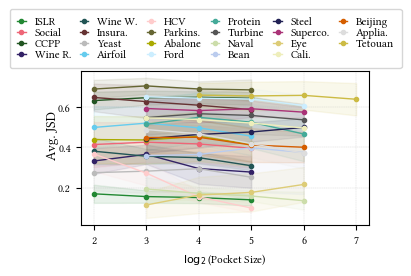

In [10]:
width_pt = 241.14749
inches_per_pt = 1.0 / 72.27  
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.77

plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    # 'legend.fontweight': 'regular',
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})


fig, ax = plt.subplots(figsize=(fig_width, fig_height))
arts = []
for size_to_plot in [10000, 50000, 100000, 250000]:
    for name in uci_datasets_info.keys():
        if name == 'ct_slices_axial':
            continue

        if uci_datasets_info[name]['size'] <= 10000:
            if size_to_plot != 10000:
                continue 
            pocket_sizes = [4, 8, 16, 32]
        elif uci_datasets_info[name]['size'] <= 50000:
            if size_to_plot != 50000:
                continue
            pocket_sizes = [8, 16, 32, 64]
        elif uci_datasets_info[name]['size'] <= 100000:
            if size_to_plot != 100000:
                continue
            pocket_sizes = [16, 32, 64, 128]
        else:
            continue
        # elif uci_datasets_info[name]['size'] <= 250000:
        #     if size_to_plot != 250000:
        #         continue
        #     # pocket_sizes = [512, 1024, 2048]
        #     pocket_sizes = [1024, 2048]

        measure = 'jsd'
        # summary = [['pocket', 'alpha', 'beta', 'lambda', 'score']]
        summary = [['pocket', 'alpha', 'beta', 'lambda', 'score']]
        for pocket_size in pocket_sizes:
            file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    for summary_item in results['summary'][1:]:
                        row = [pocket_size]
                        row.extend(summary_item[:4])
                        summary.append(row)
            
        summary_df = pd.DataFrame(summary[1:], columns=summary[0])
        summary_df['alpha'] = np.log10(summary_df['alpha'])
        summary_df['pocket'] = np.log2(summary_df['pocket'])
        # summary_df = (summary_df - summary_df.min()) / (summary_df.max() - summary_df.min())
        # parallel_coordinates(summary_df, 'pocket')
        # plt.show()

        avg_score = summary_df.groupby(['pocket']).agg(avg_score=('score', 'mean'), std_score=('score', 'std')).reset_index()

        # print(color_list[color_i])
        art, = ax.plot(avg_score['pocket'], avg_score['avg_score'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        ax.fill_between(avg_score['pocket'], avg_score['avg_score'] - avg_score['std_score'], avg_score['avg_score'] + avg_score['std_score'], color=color_list[name_map[name][2]], alpha=0.1)
        arts.append(art)

ax.set_xlabel(fr"$\log_{{2}}$({'Pocket Size'})", fontweight='bold')
# ax.set_xticks(pocket_sizes)
ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.25)
    
# ax.set_ylabel('Avg. JSD', fontweight='bold')
fig.supylabel('Avg. JSD', fontweight='bold')
fig.subplots_adjust(left=0.125, right=0.99, top=0.75, bottom=0.15)
fig.legend(
    handles=arts,
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.99), 
    ncol=6, 
    borderaxespad=0.0,
    handlelength=0.75, 
    borderpad=0.66,
    labelspacing=0.0,   
    columnspacing=0.81   
)

# plt.tight_layout(pad=0.0)

plt.savefig(f'./plots/score_vs_pocket.pdf', format='pdf', pad_inches=0.0)

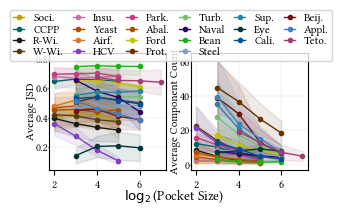

In [39]:
width_pt = 241.14749 #506.295
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.75 # Adjusted for a 1x3 horizontal layout

# 2. Plotting Setup (using LaTeX styling)
plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

avg_scores = []
avg_clusters = []

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(fig_width, fig_height))
arts = []
for size_to_plot in [10000, 50000, 100000, 250000]:
    for name in uci_datasets_info.keys():
        if name == 'ct_slices_axial':
            continue

        if uci_datasets_info[name]['size'] <= 10000:
            if size_to_plot != 10000:
                continue 
            pocket_sizes = [4, 8, 16, 32]
        elif uci_datasets_info[name]['size'] <= 50000:
            if size_to_plot != 50000:
                continue
            pocket_sizes = [8, 16, 32, 64]
        elif uci_datasets_info[name]['size'] <= 100000:
            if size_to_plot != 100000:
                continue
            pocket_sizes = [16, 32, 64, 128]
        # elif uci_datasets_info[name]['size'] <= 200000:
        #     if size_to_plot != 200000:
        #         continue
        #     pocket_sizes = [32, 64, 128, 256]
        else:
            continue

        measure = 'jsd'
        # summary = [['pocket', 'alpha', 'beta', 'lambda', 'score']]
        summary = [['pocket', 'alpha', 'beta', 'lambda', 'score', 'num_nodes', 'num_clusters', 'runtime']]
        for pocket_size in pocket_sizes:
            file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    for summary_item in results['summary'][1:]:
                        row = [pocket_size]
                        row.extend(summary_item)
                        summary.append(row)
            
        summary_df = pd.DataFrame(summary[1:], columns=summary[0])
        summary_df['og_pocket'] = summary_df['pocket']
        summary_df['alpha'] = np.log10(summary_df['alpha'])
        summary_df['pocket'] = np.log2(summary_df['pocket'])
        # summary_df = (summary_df - summary_df.min()) / (summary_df.max() - summary_df.min())
        # parallel_coordinates(summary_df, 'pocket')
        # plt.show()

        avg_values = summary_df.groupby(['pocket']).agg(
            avg_score=('score', 'mean'),
            std_score=('score', 'std'),
            avg_runtime=('runtime', 'mean'), 
            std_runtime=('runtime', 'std'),
            avg_cluster=('num_clusters', 'mean'),
            std_cluster=('num_clusters', 'std')
        ).reset_index()

        avg_og_values = summary_df.groupby(['og_pocket']).agg(
            avg_score=('score', 'mean'),
            std_score=('score', 'std'),
            avg_cluster=('num_clusters', 'mean'),
            std_cluster=('num_clusters', 'std')
        ).reset_index()

        avg_scores.extend(avg_og_values[['og_pocket', 'avg_score']].values.tolist())
        avg_clusters.extend(avg_og_values[['og_pocket', 'avg_cluster']].values.tolist())

        # print(color_list[color_i])
        art, = axes[0].plot(avg_values['pocket'], avg_values['avg_score'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        axes[0].fill_between(avg_values['pocket'], avg_values['avg_score'] - avg_values['std_score'], avg_values['avg_score'] + avg_values['std_score'], color=color_list[name_map[name][2]], alpha=0.1)
        arts.append(art)

        axes[1].plot(avg_values['pocket'], avg_values['avg_cluster'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        axes[1].fill_between(avg_values['pocket'], avg_values['avg_cluster'] - avg_values['std_cluster'], avg_values['avg_cluster'] + avg_values['std_cluster'], color=color_list[name_map[name][2]], alpha=0.1)
        
        # axes[2].plot(avg_values['pocket'], avg_values['avg_runtime'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        # axes[2].fill_between(avg_values['pocket'], avg_values['avg_runtime'] - avg_values['std_runtime'], avg_values['avg_runtime'] + avg_values['std_runtime'], color=color_list[name_map[name][2]], alpha=0.1)
        

axes[0].set_ylabel("Average JSD", fontweight='bold', labelpad=-1.0)
axes[1].set_ylabel("Average Component Count", fontweight='bold', labelpad=-1.0)
# axes[2].set_ylabel("Average Runtime (s)", fontweight='bold')
# ax.set_xticks(pocket_sizes)

axes[0].grid(True, linestyle='--', alpha=0.7, linewidth=0.25)
axes[1].grid(True, linestyle='--', alpha=0.7, linewidth=0.25)
# axes[2].grid(True, linestyle='--', alpha=0.7, linewidth=0.25)

axes[0].set_box_aspect(1)
axes[1].set_box_aspect(1)
# axes[2].set_box_aspect(1)

axes[0].tick_params(axis='y', pad=0.01, length=0.75)
axes[1].tick_params(axis='y', pad=0.01, length=0.75)

# axes[0].set_xlabel(fr"$\log_{{2}}$({'Pocket Size'})")
# axes[1].set_xlabel(fr"$\log_{{2}}$({'Pocket Size'})")

# axes[0].set_xticks([2, 3, 4, 5, 6, 7])
# axes[1].set_xticks([2, 3, 4, 5, 6, 7])
# axes[2].set_xticks([2, 3, 4, 5, 6, 7])
    
# ax.set_ylabel('Avg. JSD', fontweight='bold')
fig.supxlabel(fr"$\log_{{2}}$({'Pocket Size'})", fontweight='bold', y=0.12)

# fig.subplots_adjust(left=0.125, right=0.99, top=0.75, bottom=0.15)
# fig.subplots_adjust(left=0.01, right=1.0, top=0.99, bottom=0.2, wspace=0.25)
fig.subplots_adjust(wspace=0.21)
leg = fig.legend(
    handles=arts,
    loc='upper center', 
    bbox_to_anchor=(0.49, 0.90), 
    ncol=6, 
    borderaxespad=0.0,
    handlelength=1.0, 
    borderpad=0.3,
    labelspacing=0.025,   
    columnspacing=0.81   
)

# plt.tight_layout()

plt.savefig(f'./plots/values_vs_pocket.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

In [40]:
avg_scores = np.array(avg_scores)
avg_clusters = np.array(avg_clusters)

scores_cc = np.corrcoef(avg_scores, rowvar=False)
clusters_cc = np.corrcoef(avg_clusters, rowvar=False)

print(scores_cc)
print(clusters_cc)

[[1.         0.02977448]
 [0.02977448 1.        ]]
[[ 1.         -0.23966878]
 [-0.23966878  1.        ]]


==============================================================================================================================================================================
==============================================================================================================================================================================

/tmp/ipykernel_303045/3524886979.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


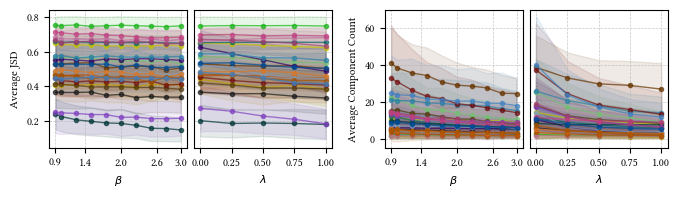

In [12]:
measure = 'jsd'
summaries = []
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [256, 512, 1024, 2048]
    
    for pocket_size in pocket_sizes:
        file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
            
            summary_df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
            summary_df.insert(loc=0, column='dataset', value=[name]*summary_df.shape[0])
            summary_df = summary_df[(summary_df['beta'] >= 0.9) & (summary_df['beta'] <= 3.0)]

            summaries.append(summary_df)

summary_df = pd.concat(summaries, axis=0)

width_pt = 506.295
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.40

# 2. Plotting Setup (using LaTeX styling)
plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

param_ticks = {
    # "alpha": [-3, -2, -1, 0, 1],
    "beta": [0.9, 1.4, 2.0, 2.6, 3.0],
    "lambda": [0, 0.25, 0.5, 0.75, 1.0]
}

# Assuming your DataFrame is named 'agg_summary' and has the columns:
# ['dataset', 'alpha', 'beta', 'lambda', 'avg_score']

fig = plt.figure(figsize=(fig_width, fig_height))

subfigs = fig.subfigures(1, 2, wspace=-0.08)

axes = [None, None]
axes[0] = subfigs[0].subplots(1, 2, sharey=True, gridspec_kw={'wspace': 0.05})
axes[1] = subfigs[1].subplots(1, 2, sharey=True, gridspec_kw={'wspace': 0.05})

# parameters = ['alpha', 'beta', 'lambda']
parameters = ['beta', 'lambda']
unique_datasets = summary_df['dataset'].unique()

# Choose a colormap to distinguish the 21 datasets
# colors = plt.cm.tab20(np.linspace(0, 1, len(unique_datasets)))

beta_score = []
beta_cluster = []
lambda_score = []
lambda_cluster = []

for t, target in enumerate(['score', 'num_clusters']):
    for i, param in enumerate(parameters):
        ax = axes[t][i]
        
        # Calculate mean and std for the current parameter, grouped by dataset
        grouped = summary_df.groupby(['dataset', param])[target].agg(['mean', 'std']).reset_index()
        
        # Plot a line for each dataset
        for j, ds in enumerate(unique_datasets):
            if ds == 'sepsis_survival_primary_cohort':
                continue

            ds_data = grouped[grouped['dataset'] == ds]
            
            ds_data = ds_data.sort_values(by=param)

            if param == 'beta':
                if target == 'score':
                    beta_score.extend(ds_data[[param, 'mean']].values.tolist())
                elif target == 'num_clusters':
                    beta_cluster.extend(ds_data[[param, 'mean']].values.tolist())
            elif param == 'lambda':
                if target == 'score':
                    lambda_score.extend(ds_data[[param, 'mean']].values.tolist())
                elif target == 'num_clusters':
                    lambda_cluster.extend(ds_data[[param, 'mean']].values.tolist())
            
            # ax.plot(ds_data[param], ds_data['mean'], marker=name_map[ds][1], color=color_list[j], alpha=0.7)
            ax.plot(ds_data[param], ds_data['mean'], marker='o', color=color_list[name_map[ds][2]], alpha=0.7)
            
            ax.fill_between(
                ds_data[param], 
                ds_data['mean'] - ds_data['std'], 
                ds_data['mean'] + ds_data['std'], 
                color=color_list[name_map[ds][2]], 
                alpha=0.1
            )
        
        xlabel = fr"$\{param}$"
        if param == 'alpha':
            xlabel = fr"$\log_{{10}}{{\{param}}}$"
        ax.set_xlabel(xlabel, fontweight='bold') # Using LaTeX rendering for greek letters
        ax.set_xticks(param_ticks[param])
        ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

axes[0][0].set_ylabel('Average JSD', fontweight='bold')
axes[1][0].set_ylabel('Average Component Count', fontweight='bold')
axes[0][1].tick_params(axis='y', length=0)
axes[1][1].tick_params(axis='y', length=0)

axes[0][0].set_box_aspect(1)
axes[0][1].set_box_aspect(1)
axes[1][0].set_box_aspect(1)
axes[1][1].set_box_aspect(1)

# fig.supylabel("Average JSD", fontweight='bold', x=-0.06)

# shift = 0.3
# for ax in axes[2:]:
#     pos = ax.get_position()
#     ax.set_position([pos.x0 + shift, pos.y0, pos.width, pos.height])

# fig.subplots_adjust(wspace=0.1)

# Automatically adjust internal padding
plt.tight_layout(pad=0.1)

# Save strictly to the 506.295pt width
plt.savefig('./plots/parameter_trends.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

/tmp/ipykernel_303045/3128975426.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


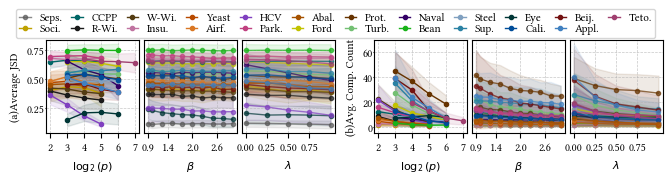

In [38]:
measure = 'jsd'
summaries = []
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [256, 512, 1024, 2048]
    
    for pocket_size in pocket_sizes:
        file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
            
            summary_df = pd.DataFrame(results['summary'][1:], columns=results['summary'][0])
            summary_df.insert(loc=0, column='dataset', value=[name]*summary_df.shape[0])
            summary_df = summary_df[(summary_df['beta'] >= 0.9) & (summary_df['beta'] <= 3.0)]

            summaries.append(summary_df)

summary_df = pd.concat(summaries, axis=0)

width_pt = 506.295
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.40

# 2. Plotting Setup (using LaTeX styling)
plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

param_ticks = {
    # "alpha": [-3, -2, -1, 0, 1],
    "beta": [0.9, 1.4, 2.0, 2.6],
    "lambda": [0, 0.25, 0.5, 0.75],
    "pocket": [2, 3, 4, 5, 6, 7]
}

# Assuming your DataFrame is named 'agg_summary' and has the columns:
# ['dataset', 'alpha', 'beta', 'lambda', 'avg_score']

fig = plt.figure(figsize=(fig_width, fig_height))

subfigs = fig.subfigures(1, 2, wspace=-0.12)

axes = [None, None]
axes[0] = subfigs[0].subplots(1, 3, sharey=True, gridspec_kw={'wspace': 0.05})
axes[1] = subfigs[1].subplots(1, 3, sharey=True, gridspec_kw={'wspace': 0.05})

# parameters = ['alpha', 'beta', 'lambda']
parameters = ['beta', 'lambda']
unique_datasets = summary_df['dataset'].unique()

# Choose a colormap to distinguish the 21 datasets
# colors = plt.cm.tab20(np.linspace(0, 1, len(unique_datasets)))

beta_score = []
beta_cluster = []
lambda_score = []
lambda_cluster = []

arts = []
for t, target in enumerate(['score', 'num_clusters']):
    for i, param in enumerate(parameters):
        ax = axes[t][i+1]
        
        # Calculate mean and std for the current parameter, grouped by dataset
        grouped = summary_df.groupby(['dataset', param])[target].agg(['mean', 'std']).reset_index()
        
        # Plot a line for each dataset
        for j, ds in enumerate(unique_datasets):
            ds_data = grouped[grouped['dataset'] == ds]
            
            ds_data = ds_data.sort_values(by=param)
            
            art, = ax.plot(ds_data[param], ds_data['mean'], marker='o', color=color_list[name_map[ds][2]], alpha=0.7, label=f'{name_map[ds][0]}')
            
            if ds == 'sepsis_survival_primary_cohort' and len(arts) == 0:
                arts.append(art)

            ax.fill_between(
                ds_data[param], 
                ds_data['mean'] - ds_data['std'], 
                ds_data['mean'] + ds_data['std'], 
                color=color_list[name_map[ds][2]], 
                alpha=0.1
            )
        
        xlabel = fr"$\{param}$"
        if param == 'alpha':
            xlabel = fr"$\log_{{10}}{{\{param}}}$"
        ax.set_xlabel(xlabel, fontweight='bold') # Using LaTeX rendering for greek letters
        ax.set_xticks(param_ticks[param])
        ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

for size_to_plot in [10000, 50000, 100000, 250000]:
    for name in uci_datasets_info.keys():
        if name == 'ct_slices_axial':
            continue

        if uci_datasets_info[name]['size'] <= 10000:
            if size_to_plot != 10000:
                continue 
            pocket_sizes = [4, 8, 16, 32]
        elif uci_datasets_info[name]['size'] <= 50000:
            if size_to_plot != 50000:
                continue
            pocket_sizes = [8, 16, 32, 64]
        elif uci_datasets_info[name]['size'] <= 100000:
            if size_to_plot != 100000:
                continue
            pocket_sizes = [16, 32, 64, 128]
        # elif uci_datasets_info[name]['size'] <= 200000:
        #     if size_to_plot != 250000:
        #         continue
        #     pocket_sizes = [256, 512, 1024, 2048]
        else:
            continue

        measure = 'jsd'
        summary = [['pocket', 'alpha', 'beta', 'lambda', 'score', 'num_nodes', 'num_clusters', 'runtime']]
        for pocket_size in pocket_sizes:
            file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    for summary_item in results['summary'][1:]:
                        row = [pocket_size]
                        row.extend(summary_item)
                        summary.append(row)
            
        summary_df = pd.DataFrame(summary[1:], columns=summary[0])
        summary_df['pocket'] = np.log2(summary_df['pocket'])

        avg_values = summary_df.groupby(['pocket']).agg(
            avg_score=('score', 'mean'),
            std_score=('score', 'std'),
            avg_cluster=('num_clusters', 'mean'),
            std_cluster=('num_clusters', 'std')
        ).reset_index()

        # print(color_list[color_i])
        art, = axes[0][0].plot(avg_values['pocket'], avg_values['avg_score'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        axes[0][0].fill_between(avg_values['pocket'], avg_values['avg_score'] - avg_values['std_score'], avg_values['avg_score'] + avg_values['std_score'], color=color_list[name_map[name][2]], alpha=0.1)
        arts.append(art)

        axes[1][0].plot(avg_values['pocket'], avg_values['avg_cluster'], label=f'{name_map[name][0]}', marker='o', color=color_list[name_map[name][2]])
        axes[1][0].fill_between(avg_values['pocket'], avg_values['avg_cluster'] - avg_values['std_cluster'], avg_values['avg_cluster'] + avg_values['std_cluster'], color=color_list[name_map[name][2]], alpha=0.1)

axes[0][0].set_xlabel(r'$\log_2\left(p\right)$', fontweight='bold')
axes[1][0].set_xlabel(r'$\log_2\left(p\right)$', fontweight='bold')

axes[0][0].set_xticks(param_ticks['pocket'])
axes[0][0].grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

axes[1][0].set_xticks(param_ticks['pocket'])
axes[1][0].grid(True, linestyle='--', alpha=0.7, linewidth=0.5)

axes[0][0].set_ylabel('(a)Average JSD', fontweight='bold')
axes[1][0].set_ylabel('(b)Avg. Comp. Count', fontweight='bold')
axes[0][1].tick_params(axis='y', length=0)
axes[0][2].tick_params(axis='y', length=0)
axes[1][1].tick_params(axis='y', length=0)
axes[1][2].tick_params(axis='y', length=0)

axes[0][0].set_box_aspect(1)
axes[0][1].set_box_aspect(1)
axes[0][2].set_box_aspect(1)
axes[1][0].set_box_aspect(1)
axes[1][1].set_box_aspect(1)
axes[1][2].set_box_aspect(1)

axes[0][0].tick_params(axis='y', pad=0.01, length=0.75)
axes[1][0].tick_params(axis='y', pad=0.01, length=0.75)

# subfigs[0].supxlabel("(a)", fontweight='bold', y=0.13)
# subfigs[1].supxlabel("(b)", fontweight='bold', y=0.13)

leg = fig.legend(
    handles=arts,
    loc='upper center', 
    bbox_to_anchor=(0.48, 0.77), 
    ncol=12, 
    borderaxespad=0.0,
    handlelength=1.0, 
    borderpad=0.3,
    labelspacing=0.01,   
    columnspacing=0.81   
)

# fig.subplots_adjust(wspace=0.05)

plt.tight_layout()

# Save strictly to the 506.295pt width
plt.savefig('./plots/parameter_all_trends.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

In [203]:
beta_scores = np.array(beta_score)
beta_cluster = np.array(beta_cluster)
lambda_scores = np.array(lambda_score)
lambda_cluster = np.array(lambda_cluster)

beta_score_cc = np.corrcoef(beta_scores, rowvar=False)
beta_cluster_cc = np.corrcoef(beta_cluster, rowvar=False)
lambda_score_cc = np.corrcoef(lambda_scores, rowvar=False)
lambda_cluster_cc = np.corrcoef(lambda_cluster, rowvar=False)

print(beta_score_cc)
print(beta_cluster_cc)
print(lambda_score_cc)
print(lambda_cluster_cc)

[[ 1.         -0.04983969]
 [-0.04983969  1.        ]]
[[ 1.         -0.20881577]
 [-0.20881577  1.        ]]
[[ 1.         -0.10547277]
 [-0.10547277  1.        ]]
[[ 1.         -0.32762772]
 [-0.32762772  1.        ]]


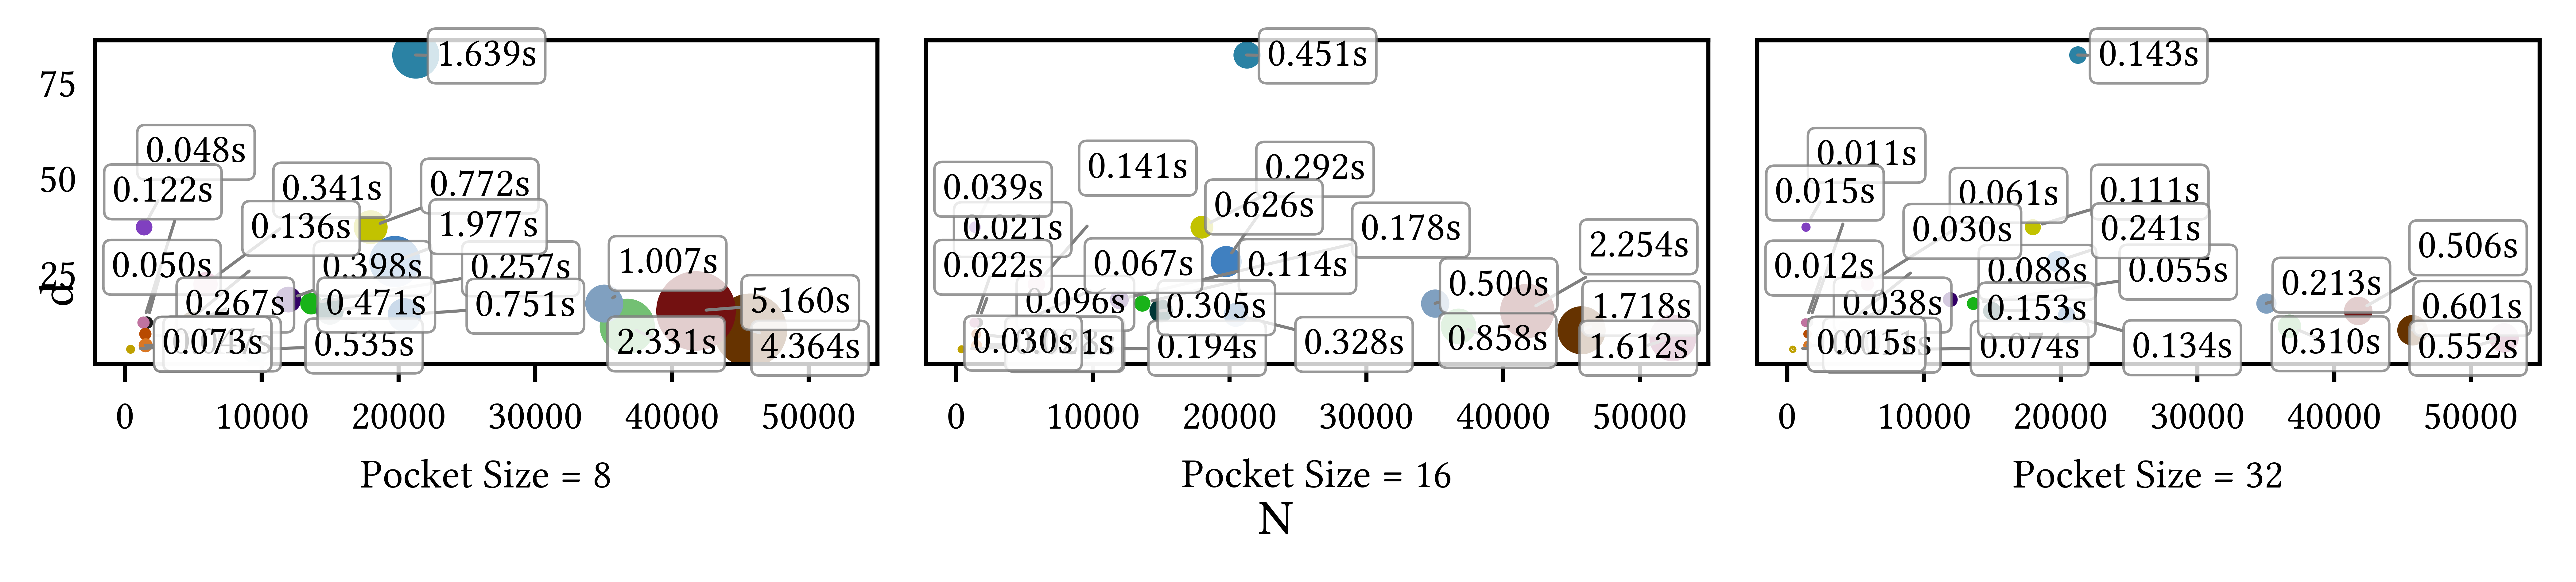

In [10]:
width_pt = 506.295
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.2 # Adjusted for a 1x3 horizontal layout

# 2. Plotting Setup (using LaTeX styling)
plt.rcParams.update({
    'font.family': custom_font, # Ensure custom_font is defined in your scope
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, axes = plt.subplots(1, 3, sharey=True, sharex=True, figsize=(fig_width, fig_height), dpi=1200)
arts = []

pocket_map = {8:0, 16:1, 32:2}

# --- ADDED: Dictionary to store text objects for each axis ---
texts_per_ax = {0: [], 1: [], 2: []} 

for name in uci_datasets_info.keys():
    if name == 'ct_slices_axial':
        continue

    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32] 
    else:
        continue

    df = pd.read_csv(f'./datasets/{name}.csv', delimiter=uci_datasets_info[name]['delim'])
    df, mapping, _ = preprocess_dataframe(df, uci_datasets_info[name]['target_variable'][0], uci_datasets_info[name]['categorical_variables'], uci_datasets_info[name]['id_variables'])
    num_rows, num_cols = df.shape

    measure = 'jsd'
    summary = [['pocket', 'runtime']]
    for pocket_size in pocket_sizes:
        file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
                for summary_item in results['summary'][1:]:
                    row = [pocket_size]
                    row.extend([summary_item[-1]])
                    summary.append(row)
        
    summary_df = pd.DataFrame(summary[1:], columns=summary[0])

    avg_runtime = summary_df.groupby(['pocket']).agg(
        avg_runtime=('runtime', 'mean'),
        std_runtime=('runtime', 'std')
    ).reset_index()

    for p_size in avg_runtime['pocket'].unique():
        if p_size in pocket_map:
            bubble_ratio = (1000 / 24.357542753219604)
            the_runtime = avg_runtime[avg_runtime['pocket'] == p_size]['avg_runtime'].item()
            ax_idx = pocket_map[p_size]
            
            axes[ax_idx].scatter(
                [num_rows], 
                [num_cols], 
                color=color_list[name_map[name][2]], 
                sizes=[bubble_ratio * the_runtime]
            )

            # --- ADDED: Create the text box at the point's exact location ---
            # We add it to our tracking list to be adjusted later.
            txt = axes[ax_idx].text(
                num_rows, 
                num_cols, 
                f"{the_runtime:.3f}s", 
                fontsize=8, 
                # Create a clear box: white background, gray edge, slightly rounded
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5, alpha=0.8)
            )
            texts_per_ax[ax_idx].append(txt)

for i in range(3):
    # axes[i].set_box_aspect(1)
    axes[i].tick_params(axis='y', length=0)
    axes[i].set_xlabel(f"Pocket Size = {2**(3+i)}", fontweight='bold')
    
    # --- ADDED: Repel text boxes and draw headless lines ---
    if texts_per_ax[i]:
        adjust_text(
            texts_per_ax[i], 
            ax=axes[i], 
            # arrowstyle="-" creates a line with NO arrowhead
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.6)
        )

fig.supxlabel("N", fontweight='bold')
fig.supylabel("d", fontweight='bold')

fig.subplots_adjust(left=0.00, right=1.02, top=0.86, bottom=0.16, wspace=2.5)

# Suppress the warning that tight_layout throws when combined with subplots_adjust
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.tight_layout(pad=0.1)

plt.savefig(f'./plots/runtimes.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

/tmp/ipykernel_85631/2895972065.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synthetic_df = pd.concat([synthetic_df, c_df], ignore_index=True)
/tmp/ipykernel_85631/2895972065.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synthetic_df = pd.concat([synthetic_df, n_df], ignore_index=True)


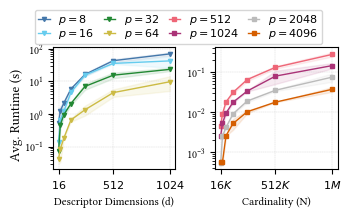

In [20]:
width_pt = 241.14749
inches_per_pt = 1.0 / 72.27  
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.7

plt.rcParams.update({
    'font.family': custom_font,
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    # 'legend.fontweight': 'regular',
    'lines.linewidth': 1,
    'lines.markersize': 3,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(1, 2, sharey=False, figsize=(fig_width, fig_height))
arts = []

Cs = [16, 32, 64, 128, 256, 512, 1024]
synthetic_df = pd.DataFrame(columns=['C', 'pocket_size', 'runtime'])
for C in Cs:
    with open(f'./results/mod/synthetic_C{C}.pkl', 'rb') as f:
        synthetic_summary = pickle.load(f)
        c_df = pd.DataFrame(synthetic_summary[1:], columns=synthetic_summary[0])
        c_df['C'] = int(C)
        synthetic_df = pd.concat([synthetic_df, c_df], ignore_index=True)

avg_runtime = synthetic_df.groupby(['C', 'pocket_size'], as_index=False).agg(
    avg_runtime=('runtime', 'mean'), 
    std_runtime=('runtime', 'std')).reset_index()

avg_runtime['C'] = avg_runtime['C'].astype(int)

color_i = 0 # this is common for both the following loops.
for pocket_size in avg_runtime['pocket_size'].unique():
    avg_runtime_C = avg_runtime[avg_runtime['pocket_size'] == pocket_size]
    
    art, = ax[0].plot(
                avg_runtime_C['C'], 
                avg_runtime_C['avg_runtime'], 
                marker='v', 
                color=cb_color_list[color_i],
                label=fr'$p={pocket_size}$'
            )
    ax[0].fill_between(
        avg_runtime_C['C'], 
        avg_runtime_C['avg_runtime'] - avg_runtime_C['std_runtime'], 
        avg_runtime_C['avg_runtime'] + avg_runtime_C['std_runtime'], 
        color=cb_color_list[color_i], 
        alpha=0.1
    )

    arts.append(art)
    color_i += 1

ax[0].set_xlabel("Descriptor Dimensions (d)", fontweight='bold')
# ax[0].set_yscale('log')
# ax.set_xticks(pocket_sizes)
# ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
ax[0].grid(True, linestyle='--', alpha=0.7, linewidth=0.25)

ax[0].set_xticks([16, 512, 1024])
ax[0].set_xticklabels([r'$16$', r'$512$', r'$1024$'])

ax[0].set_box_aspect(1)
ax[0].set_yscale('log')
# ax[0].set_xscale('log')
        
# ax.set_ylabel('Avg. JSD', fontweight='bold')
# fig.supylabel('Avg. Runtime (s)', fontweight='bold')
# fig.subplots_adjust(left=0.13, right=1.0, top=1.0, bottom=0.13)

# plt.tight_layout(pad=0.0)

# plt.savefig(f'./plots/runtime_vs_d.pdf', format='pdf', pad_inches=0.0)

###############################################################################

Ns = [16000, 32000, 64000, 128000, 256000, 512000, 1024000]
synthetic_df = pd.DataFrame(columns=['N', 'pocket_size', 'runtime'])
for N in Ns:
    with open(f'./results/mod/synthetic_N{N}.pkl', 'rb') as f:
        synthetic_summary = pickle.load(f)
        n_df = pd.DataFrame(synthetic_summary[1:], columns=synthetic_summary[0])
        n_df['N'] = int(N)
        synthetic_df = pd.concat([synthetic_df, n_df], ignore_index=True)

synthetic_df['N'] = synthetic_df['N'].astype(int)
# synthetic_df['V'] = synthetic_df['N'] / synthetic_df['pocket_size']

avg_runtime = synthetic_df.groupby(['N', 'pocket_size'], as_index=False).agg(
    avg_runtime=('runtime', 'mean'), 
    std_runtime=('runtime', 'std')).reset_index()

# fig, ax = plt.subplots(figsize=(fig_width, fig_height))
# for v in avg_runtime['V'].unique():
#     avg_runtime_N = avg_runtime[avg_runtime['V'] == v]
for pocket_size in avg_runtime['pocket_size'].unique():
    avg_runtime_N = avg_runtime[avg_runtime['pocket_size'] == pocket_size]

    # print(avg_runtime_N)

    art, = ax[1].plot(
                avg_runtime_N['N'], 
                avg_runtime_N['avg_runtime'], 
                marker='s', 
                color=cb_color_list[color_i],
                label=fr'$p={pocket_size}$'
            )
    ax[1].fill_between(
        avg_runtime_N['N'], 
        avg_runtime_N['avg_runtime'] - avg_runtime_N['std_runtime'], 
        avg_runtime_N['avg_runtime'] + avg_runtime_N['std_runtime'], 
        color=cb_color_list[color_i], 
        alpha=0.1
    )

    arts.append(art)
    color_i += 1

    ax[1].set_xlabel("Cardinality (N)", fontweight='bold')
    # ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
    # ax[1].set_yscale('log')
    # ax[1].set_xticks([16000, 512000, 1024000])
    ax[1].grid(True, linestyle='--', alpha=0.7, linewidth=0.25)

    ax[1].set_xticks([16000, 512000, 1024000])
    # ax[1].set_xticklabels([r'$2^4$', r'$2^9$', r'$2^{10}$'])
    ax[1].set_xticklabels([r'$16K$', r'$512K$', r'$1M$'])

    ax[1].set_box_aspect(1)
    ax[1].set_yscale('log')
    # ax[1].set_xscale('log')
        
# ax.set_ylabel('Avg. JSD', fontweight='bold')
fig.supylabel('Avg. Runtime (s)', fontweight='bold', x=0.005)
fig.subplots_adjust(wspace=0.01)

leg = fig.legend(
    handles=arts,
    loc='upper center', 
    bbox_to_anchor=(0.51, 0.95), 
    ncol=4, 
    borderaxespad=0.0,
    handlelength=1.0, 
    borderpad=0.3,
    labelspacing=0.01,   
    columnspacing=0.81   
)

plt.tight_layout(pad=0.1)

plt.savefig(f'./plots/runtime_vs_d_N.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

In [45]:
rows = [['dataset', 'jsd']]
for name in uci_datasets_info.keys():
    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [4, 8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32, 64]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32, 64, 128]
    elif uci_datasets_info[name]['size'] <= 250000:
        pocket_sizes = [512, 1024, 2048]

    the_best = []
    for measure in ['jsd']:
        is_all_done = True
        best_of_each = []
        for pocket_size in pocket_sizes:
            file = f'./results/ablation/{name}_p{pocket_size}.pkl'
            if os.path.isfile(file):
                with open(file, 'rb') as f:
                    results = pickle.load(f)
                    # the_values = [results['best_scores'][0]]
                    # the_values.extend(list(results['best_configs'][0])[1:])
                    # best_of_each.append(the_values)
                    # best_ratio = -float('inf')
                    # best_i = 0
                    # for i in range(3):
                    #     ratio = results['best_scores'][i] / len(results['best_details'][i]['clusters'])
                    #     if ratio > best_ratio:
                    #         best_ratio = ratio
                    #         best_i = i
                    
                    best_i = 0
                    best_of_each.append(results['best_scores'][best_i])
            else:
                is_all_done = False
                break
        
        if is_all_done:
            # the_best.append(max(best_of_each, key=lambda x: x[0]))
            the_best.append(max(best_of_each))
    
    if len(the_best) == 1:
        new_row = [name]
        new_row.extend(the_best)
        rows.append(new_row)

ablation_df = pd.DataFrame(rows[1:], columns=rows[0])

In [46]:
combined_df = best_df[['dataset', 'jsd']].merge(ablation_df[['dataset', 'jsd']], on='dataset', how='left', suffixes=('_scout', '_scout_solo'))
combined_df = combined_df.round(3)
combined_df = combined_df.fillna(-1)
combined_df

,dataset,jsd_scout,jsd_scout_solo
0,sepsis_survival_primary_cohort,0.167,0.155
1,social_network_ads,0.660,0.468
2,uk_used_cars_ford,0.723,0.653
3,combined_cycle_power_plant,0.740,0.721
4,protein_tertiary_structure,0.683,0.424
5,gas_turbine_emissions,0.722,0.644
6,naval_propulsion_plants,0.741,0.507
7,winequality-red,0.540,0.475
8,winequality-white,0.532,0.408
9,dry_bean,0.816,0.814


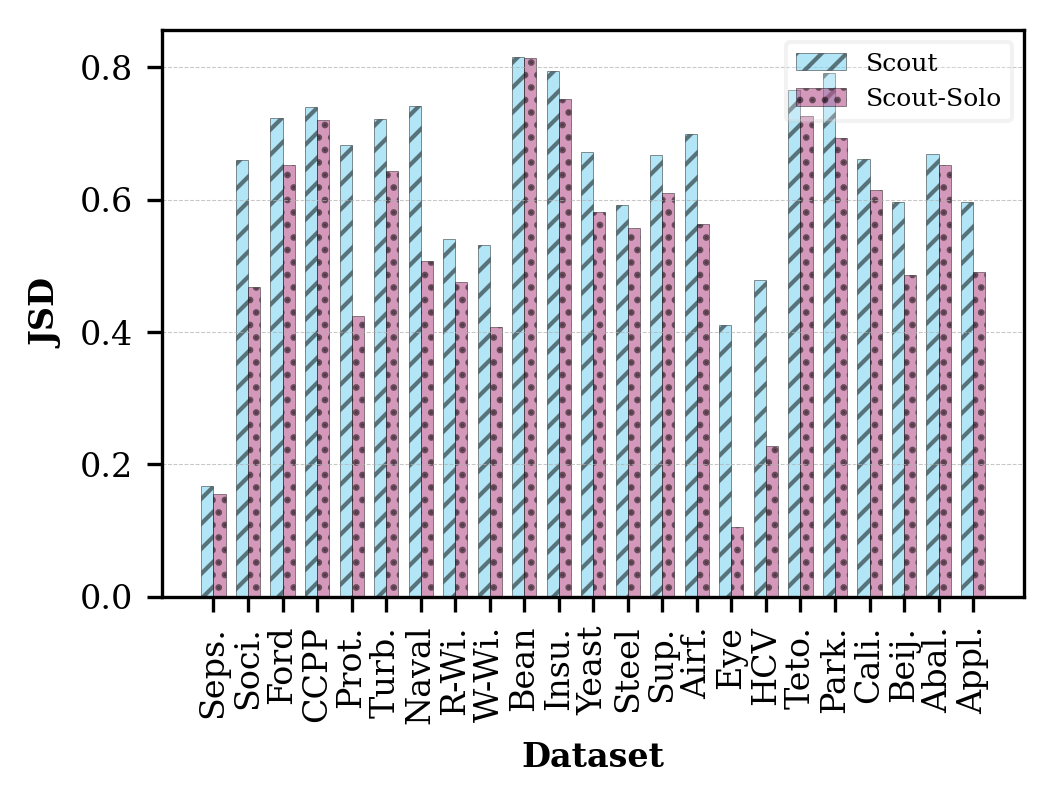

In [47]:
width_pt = 241.14749
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=300)

x = np.array(range(len(combined_df['dataset']))) * 2
width = np.ones(len(combined_df['dataset'])) * 0.7

# bar_colors = [color_list[name_map[ds][2]] for ds in combined_df['dataset']]
bars_scout = ax.bar(
    x - (width/2), 
    combined_df['jsd_scout'], 
    width, 
    color=CB_palette['CBcyan'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='////',
    label='Scout',
    align='center'
)
               
bars_solo = ax.bar(
    x + (width/2), 
    combined_df['jsd_scout_solo'], 
    width, 
    color=CB_palette['CBpurple'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='....',
    label='Scout-Solo',
    align='center'
)

ax.set_ylabel('JSD', fontweight='bold')
ax.set_xlabel('Dataset', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([name_map[ds][0] for ds in combined_df['dataset']], rotation=90)

ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.25, axis='y')

# ax.set_box_aspect(1)

legend_elements = [
    Patch(facecolor='white', edgecolor='black', hatch='////', label='Scout'),
    Patch(facecolor='white', edgecolor='black', hatch='....', label='Scout-Solo')
]
ax.legend(handles=[bars_scout, bars_solo], loc='best', framealpha=0.25)

# 6. Export without white margins
plt.tight_layout(pad=0.1)
plt.savefig('./plots/scout_comparisons.pdf', format='pdf', bbox_inches='tight', pad_inches=0.0)

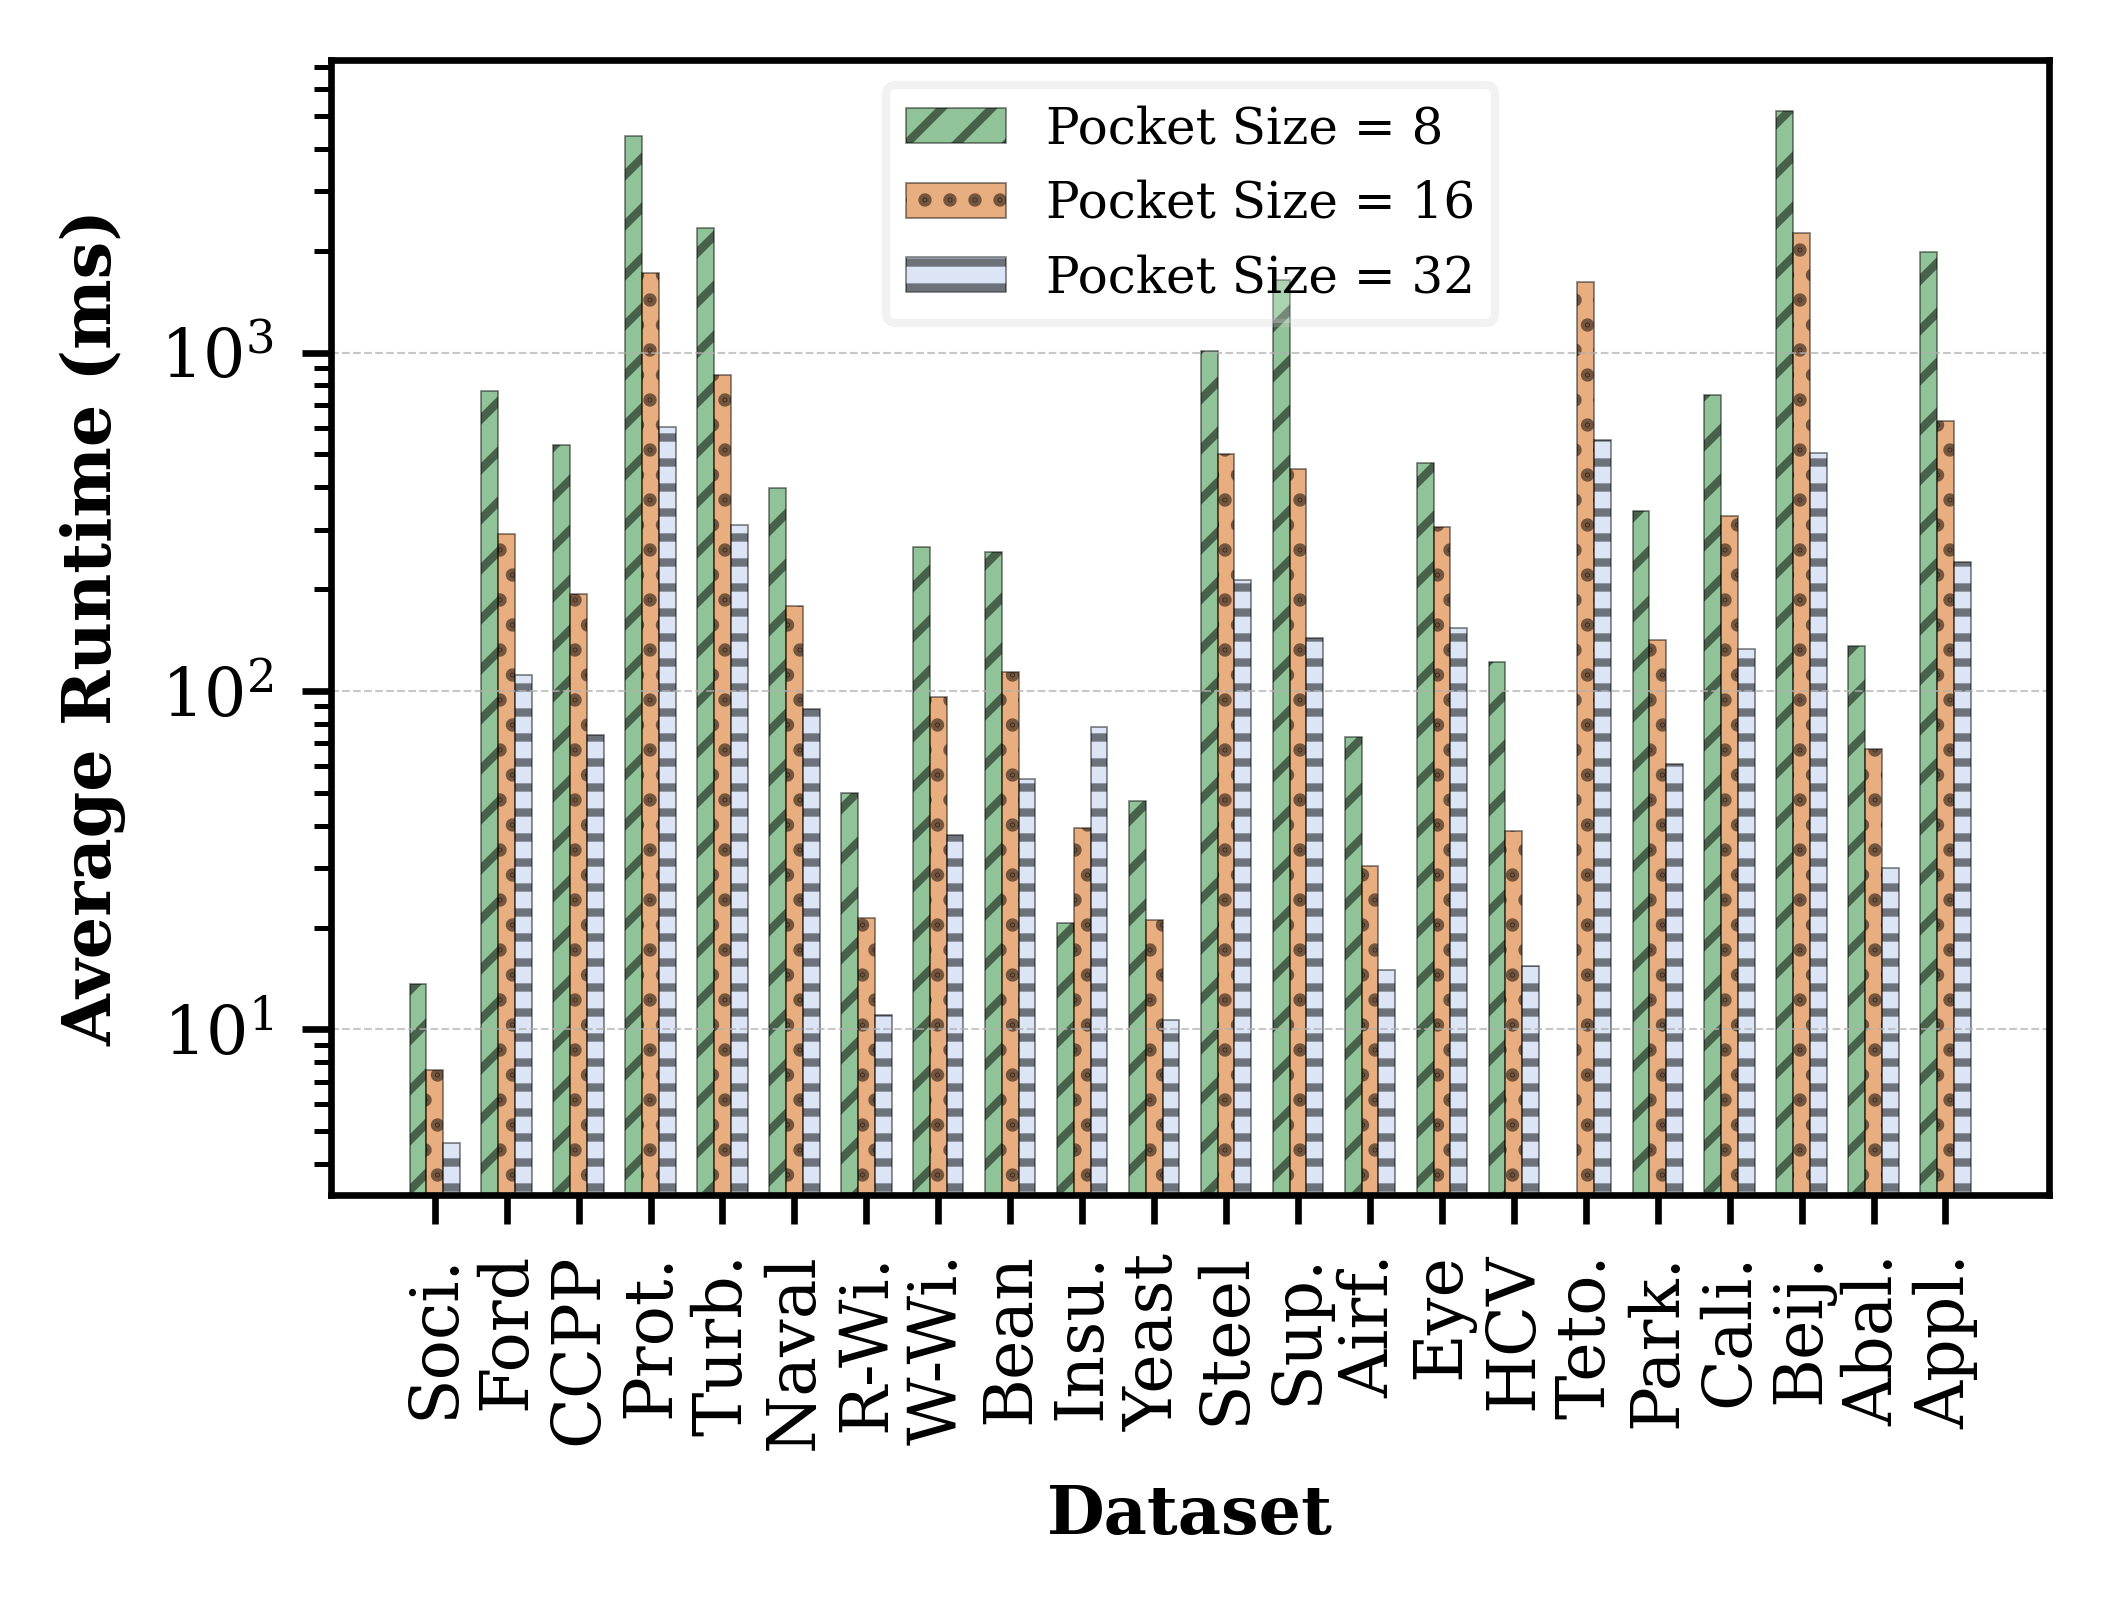

In [42]:
the_names = []

p8_avg = []
p16_avg = []
p32_avg = []

p8_std = []
p16_std = []
p32_std = []

for name in uci_datasets_info.keys():
    if name == 'ct_slices_axial':
        continue

    if uci_datasets_info[name]['size'] <= 10000:
        pocket_sizes = [8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 50000:
        pocket_sizes = [8, 16, 32]
    elif uci_datasets_info[name]['size'] <= 100000:
        pocket_sizes = [16, 32] 
    else:
        continue

    df = pd.read_csv(f'./datasets/{name}.csv', delimiter=uci_datasets_info[name]['delim'])
    df, mapping, _ = preprocess_dataframe(df, uci_datasets_info[name]['target_variable'][0], uci_datasets_info[name]['categorical_variables'], uci_datasets_info[name]['id_variables'])
    num_rows, num_cols = df.shape

    measure = 'jsd'
    summary = [['pocket', 'runtime']]
    for pocket_size in pocket_sizes:
        file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
                for summary_item in results['summary'][1:]:
                    row = [pocket_size]
                    row.extend([summary_item[-1]])
                    summary.append(row)
        
    summary_df = pd.DataFrame(summary[1:], columns=summary[0])

    avg_runtime = summary_df.groupby(['pocket']).agg(
        avg_runtime=('runtime', 'mean'),
        std_runtime=('runtime', 'std')
    ).reset_index()

    avg_runtime['avg_runtime'] = avg_runtime['avg_runtime'] * 1e3
    avg_runtime['std_runtime'] = avg_runtime['std_runtime'] * 1e3

    avg_list = avg_runtime['avg_runtime'].tolist()
    std_list = avg_runtime['std_runtime'].tolist()

    if len(avg_list) > 2:
        p8_avg.append(avg_list[0])
        p16_avg.append(avg_list[1])
        p32_avg.append(avg_list[2])

        p8_std.append(std_list[0])
        p16_std.append(std_list[1])
        p32_std.append(std_list[2])
    elif len(avg_list) == 2:
        p8_avg.append(0)
        p16_avg.append(avg_list[0])
        p32_avg.append(avg_list[1])
        
        p8_std.append(0)
        p16_std.append(std_list[0])
        p32_std.append(std_list[1])

    the_names.append(name)


width_pt = 241.14749
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt
fig_height = fig_width * 0.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=600)

x = np.array(range(len(the_names))) * 3
width = np.ones(len(the_names)) * 0.7

bars_p8 = ax.bar(
    x - width, 
    p8_avg, 
    width, 
    # yerr=p8_std,
    color=CB_palette['CBgreen'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='////',
    label='Pocket Size = 8',
    align='center'
)
               
bars_p16 = ax.bar(
    x, 
    p16_avg, 
    width, 
    # yerr=p16_std,
    color=CB_palette['CBorange'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='....',
    label='Pocket Size = 16',
    align='center'
)

bars_p32 = ax.bar(
    x + width, 
    p32_avg, 
    width, 
    # yerr=p32_std,
    color=CB_palette['CBpaleblue'], 
    alpha=0.5,
    edgecolor='black', 
    linewidth=0.2, 
    hatch='----',
    label='Pocket Size = 32',
    align='center'
)

ax.set_yscale('log')

ax.set_ylabel('Average Runtime (ms)', fontweight='bold')
ax.set_xlabel('Dataset', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([name_map[ds][0] for ds in the_names], rotation=90)

ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.25, axis='y')

ax.legend(handles=[bars_p8, bars_p16, bars_p32], loc='best', framealpha=0.25)

# 6. Export without white margins
plt.tight_layout(pad=0.1)
plt.savefig(f'./plots/runtimes_bars.pdf', format='pdf', bbox_inches='tight', pad_inches=0.01)

In [9]:
rows = [['dataset', 'jsd']]
name = 'insurance'
pocket_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
the_best = []
for measure in ['jsd']:
    # is_all_done = True
    best_of_each = []
    for pocket_size in pocket_sizes:
        file = f'./results/mod/{name}_p{pocket_size}_{measure}.pkl'
        if os.path.isfile(file):
            with open(file, 'rb') as f:
                results = pickle.load(f)
                best_i = 0
                best_of_each.append(results['best_scores'][best_i])
                print(results['best_scores'][best_i])
        # else:
        #     is_all_done = False
        #     break
    
    # if is_all_done:
    #     # the_best.append(max(best_of_each, key=lambda x: x[0]))
    the_best.append(max(best_of_each))

if len(the_best) == 1:
    new_row = [name]
    new_row.extend(the_best)
    rows.append(new_row)

0.8030251860618591
0.8337894082069397
0.7950990796089172
0.7936888337135315
0.7927003502845764
0.7926884293556213
0.7982631921768188
0.7816648483276367


,dataset,jsd
0,insurance,0.787604
